# Build Class A affinity MTL model.

This notebook shows how to build a MTL model to predict pIC50 in a few Class A GPCRs. It will be used as a basis for transfer learning other GPCRs. 

In [1]:
import os
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv, global_mean_pool
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader

from rdkit import Chem
from rdkit.Chem import Descriptors, rdPartialCharges
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold

import itertools
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

import pathlib
from pathlib import Path
from rdkit import RDLogger
from tqdm.notebook import tqdm

# Get the main logger
logger = RDLogger.logger()

# Set its level to ERROR so only serious messages show up
logger.setLevel(RDLogger.ERROR)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#verify Cuda is actually working

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version (runtime):", torch.version.cuda)

print("Torch CUDA libraries loaded:")
for lib in torch.cuda._CudaBase.__module__.split(":"):
    print(lib)

Torch version: 2.8.0+cu128
CUDA available: True
CUDA version (runtime): 12.8
Torch CUDA libraries loaded:
torch.cuda


## Setup.

In [2]:
readout = 'class_a_combined'

In [31]:
# define paths
HERE = Path(pathlib.Path.cwd())
DATA = HERE / f"data_{readout}"
DATA.mkdir(parents=True, exist_ok=True)

MIN_LIGANDS = 2000  # Minimum ligands per target to include
VALID_ACT_TYPES = {"IC50", "Ki", "EC50", "Kd"}

In [32]:
def load_target_data(file_path):
    df = pd.read_csv(file_path)
    df = df[
        (df['standard_type'].isin(VALID_ACT_TYPES)) &
        (df['standard_relation'] == '=') &
        (df['pActivity'].notna())
    ]
    return df[['smiles', 'uniprot_id', 'pActivity']]

In [33]:
all_data = []
target_ligand_counts = {}

csv_files = glob.glob(os.path.join(DATA, "*_bioactivity.csv"))
print(f"Found {len(csv_files)} files.")

for f in tqdm(csv_files):
    df = load_target_data(f)
    if df.empty:
        continue
    tid = df['uniprot_id'].iloc[0]
    count = df.shape[0]
    target_ligand_counts[tid] = count
    all_data.append(df)

selected_targets = [t for t, c in target_ligand_counts.items() if c >= MIN_LIGANDS]
print(f"Selected {len(selected_targets)} targets with >= {MIN_LIGANDS} ligands")

filtered_data = pd.concat([d for d in all_data if d['uniprot_id'].iloc[0] in selected_targets])


Found 200 files.


100%|██████████| 200/200 [00:00<00:00, 421.63it/s]

Selected 9 targets with >= 2000 ligands


In [34]:
multitask_df = filtered_data.pivot_table(
    index='smiles',
    columns='uniprot_id',
    values='pActivity',
    aggfunc='mean'
).reindex(columns=selected_targets)

print(f"Multitask matrix: {multitask_df.shape[0]} molecules × {multitask_df.shape[1]} targets")
print(f"Missing fraction: {multitask_df.isna().mean().mean():.3f}")


Multitask matrix: 17669 molecules × 9 targets
Missing fraction: 0.870


Pytorch geometric fix

In [35]:
# Here we define our own data structure for Pytorch Geometric to use in the model.
# Why? In the functions below, PyG's Batch.from_data_list tries to automatically 
# concatenate all descriptors and layers and gets the feature vector size wrong unless instructed not to. 
# (1D vector of 288 instead of 2D vector odf 32 x 9 chemical features)  
# global_features should be stacked (batched), not concatenated - the __cat_dim__ method controls that.

class MoleculeData(Data):
    def __inc__(self, key, value, *args, **kwargs):
        return super().__inc__(key, value)
    def __cat_dim__(self, key, value, *args, **kwargs):
        if key == 'global_features':
            return None
        return super().__cat_dim__(key, value)


In [36]:
def safe_value(val):
    try:
        if np.isnan(val) or np.isinf(val):
            return 0.0
        return val
    except:
        return 0.0

In [37]:
def one_hot_encoding(x, allowable_set):
    if x not in allowable_set:
        x = allowable_set[-1]
    return [int(x == s) for s in allowable_set]

## Featurisation step.

In [38]:
from rdkit.Chem import rdMolDescriptors, AllChem
from rdkit.Chem.rdchem import BondType

# --- Constants ---
electronegativity_dict = {
    1: 2.20, 6: 2.55, 7: 3.04, 8: 3.44, 9: 3.98, 15: 2.19,
    16: 2.58, 17: 3.16, 35: 2.96, 53: 2.66,
}
metals = {
    3, 4, 11, 12, 13, 19, 20, 21, 22, 23, 24, 25,
    26, 27, 28, 29, 30, 37, 38, 39, 40, 41, 42,
    43, 44, 45, 46, 47, 48, 49, 55, 56, 57, 72,
    73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83,
    87, 88, 89, 104, 105, 106, 107, 108, 109, 110,
    111, 112, 113, 114, 115, 116
}

# --- Atom features ---
def get_atom_features(atom, mol=None):
    pt = Chem.GetPeriodicTable()
    features = []

    # Atom symbol
    features += one_hot_encoding(atom.GetSymbol(),
                                 ['C', 'N', 'O', 'F', 'P', 'S', 'Cl', 'Br', 'I', 'H',
                                  'B', 'Si', 'Se', 'As', 'Al', 'Zn', 'Cu', 'Ni', 'Fe', 'other'])

    # Hybridization
    features += one_hot_encoding(atom.GetHybridization(),
                                 [Chem.rdchem.HybridizationType.SP,
                                  Chem.rdchem.HybridizationType.SP2,
                                  Chem.rdchem.HybridizationType.SP3,
                                  Chem.rdchem.HybridizationType.SP3D,
                                  Chem.rdchem.HybridizationType.SP3D2,
                                  Chem.rdchem.HybridizationType.UNSPECIFIED])

    # Integer-valued local properties
    features += [
        atom.GetDegree(),
        atom.GetFormalCharge(),
        atom.GetNumRadicalElectrons(),
        int(atom.GetIsAromatic())
    ]

    atomic_num = atom.GetAtomicNum()
    features += [
        pt.GetAtomicWeight(atomic_num) / 200,
        pt.GetRvdw(atomic_num) / 2.5,
        electronegativity_dict.get(atomic_num, 0.0) / 4.0,
        pt.GetNOuterElecs(atomic_num) / 8.0,
        1.0 if atomic_num in metals else 0.0
    ]

    # --- Partial charge ---
    if mol is not None:
        try:
            charge = float(atom.GetProp('_GasteigerCharge'))
            charge = safe_value(charge)
        except:
            charge = 0.0
        features.append(charge)
    else:
        features.append(0.0)

    # --- Additional contextual features ---
    # In-ring + ring size
    ring_info = mol.GetRingInfo() if mol is not None else None
    in_ring = ring_info.IsAtomInRingOfSize(atom.GetIdx(), 5) or ring_info.IsAtomInRingOfSize(atom.GetIdx(), 6) if ring_info else False
    features.append(float(in_ring))
    features.append(float(ring_info.NumAtomRings(atom.GetIdx()) if ring_info else 0))

    # Neighbor stats
    neighbor_atoms = [mol.GetAtomWithIdx(nb.GetIdx()) for nb in atom.GetNeighbors()] if mol else []
    neighbor_charges = []
    neighbor_electronegs = []
    for nb in neighbor_atoms:
        try:
            neighbor_charges.append(float(nb.GetProp('_GasteigerCharge')))
        except:
            neighbor_charges.append(0.0)
        neighbor_electronegs.append(electronegativity_dict.get(nb.GetAtomicNum(), 0.0))
    features.append(np.mean(neighbor_charges) if neighbor_charges else 0.0)
    features.append(np.mean(neighbor_electronegs) / 4.0 if neighbor_electronegs else 0.0)

    return np.array(features, dtype=np.float32)


# --- Bond features ---
def get_bond_features(bond):
    bond_type = bond.GetBondType()
    features = [
        int(bond_type == BondType.SINGLE),
        int(bond_type == BondType.DOUBLE),
        int(bond_type == BondType.TRIPLE),
        int(bond_type == BondType.AROMATIC),
        int(bond.GetIsConjugated()),
        int(bond.IsInRing()),
        float(bond.GetBondTypeAsDouble()),  # continuous bond order
    ]

    # Stereo (cis/trans, E/Z)
    stereo = bond.GetStereo()
    features += one_hot_encoding(stereo, [
        Chem.rdchem.BondStereo.STEREONONE,
        Chem.rdchem.BondStereo.STEREOANY,
        Chem.rdchem.BondStereo.STEREOZ,
        Chem.rdchem.BondStereo.STEREOE
    ])

    # Ring size if applicable
    ring_sizes = bond.GetOwningMol().GetRingInfo().AtomRings()
    sizes = [len(r) for r in ring_sizes if bond.GetBeginAtomIdx() in r and bond.GetEndAtomIdx() in r]
    features.append(float(min(sizes)) if sizes else 0.0)

    return np.array(features, dtype=np.float32)


# --- Global (molecular) descriptors ---
descriptor_functions = [
    Descriptors.MolWt,
    Descriptors.MolLogP,
    Descriptors.NumHDonors,
    Descriptors.NumHAcceptors,
    Descriptors.TPSA,
    Descriptors.FractionCSP3,
    Descriptors.HeavyAtomCount,
    Descriptors.NumRotatableBonds,
    Descriptors.RingCount,
    rdMolDescriptors.CalcNumAromaticRings,
    rdMolDescriptors.CalcLabuteASA,
    rdMolDescriptors.CalcChi0n,
    rdMolDescriptors.CalcKappa1,
    rdMolDescriptors.CalcKappa2,
]


## Convert Featurised molecules into graph for the model.

In [39]:
def mol_to_graph(smiles: str, label: float = None, include_fingerprint: bool = True):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    try:
        rdPartialCharges.ComputeGasteigerCharges(mol)
    except:
        pass

    atom_features = [get_atom_features(atom, mol) for atom in mol.GetAtoms()]
    x = torch.tensor(atom_features, dtype=torch.float)

    edge_index, edge_attr = [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        bond_feat = get_bond_features(bond)
        edge_index += [[i, j], [j, i]]
        edge_attr += [bond_feat, bond_feat]

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    # Global descriptors
    global_features = []
    for func in descriptor_functions:
        try:
            val = func(mol)
            if isinstance(val, tuple):  # e.g., Crippen returns (logP, MR)
                global_features.extend([safe_value(v) for v in val])
            else:
                global_features.append(safe_value(val))
        except:
            global_features.append(0.0)

    # Optional fingerprint (ECFP4)
    if include_fingerprint:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024)
        fp_tensor = np.array(list(fp), dtype=np.float32)
        global_features.extend(fp_tensor.tolist())

    global_features = torch.tensor(global_features, dtype=torch.float32)

    data = MoleculeData(x=x, edge_index=edge_index, edge_attr=edge_attr, global_features=global_features)
    if label is not None:
        data.y = torch.tensor([label], dtype=torch.float)
    data.smiles = smiles

    return data


Data loader code.

In [40]:
# We have to tell the DataLoader which features to expect.

def compute_global_features(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        # fallback vector of zeros if mol fails
        return torch.zeros(len(descriptor_functions), dtype=torch.float)
    feats = [fn(mol) for fn in descriptor_functions]
    return torch.tensor(feats, dtype=torch.float)

In [41]:
def custom_collate(batch_list):
    return Batch.from_data_list(batch_list)

In [42]:
import concurrent.futures
import multiprocessing as mp
from tqdm import tqdm
# import numpy as np
# import torch

# --- Top-level worker (must be defined in a top cell, not nested) ---
def mol_to_graph_worker(args):
    smi, label_vec = args
    try:
        # local import avoids pickling global RDKit symbols
        from rdkit import Chem
        from rdkit.Chem import AllChem, rdPartialCharges
        data = mol_to_graph(smi, label=None, include_fingerprint=True)
        if data is not None:
            data.y = torch.tensor(label_vec, dtype=torch.float).unsqueeze(0)
            return data
    except Exception:
        return None
    return None


# --- Prepare input ---
input_data = [
    (smi, multitask_df.loc[smi].values.astype(np.float32))
    for smi in multitask_df.index
]

n_jobs = max(1, mp.cpu_count() - 2)
print(f"Processing {len(input_data)} molecules using {n_jobs} processes...")

# --- Use spawn context to isolate RDKit safely ---
ctx = mp.get_context("fork")  # <-- use fork, not spawn

data_list = []
with concurrent.futures.ProcessPoolExecutor(max_workers=n_jobs, mp_context=ctx) as executor:
    for result in tqdm(executor.map(mol_to_graph_worker, input_data, chunksize=10),
                       total=len(input_data)):
        if result is not None:
            data_list.append(result)

print(f"Created {len(data_list)} valid molecular graphs out of {len(input_data)} total.")


Processing 17669 molecules using 18 processes...


/tmp/ipykernel_21947/1375517879.py:12: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  x = torch.tensor(atom_features, dtype=torch.float)
/tmp/ipykernel_21947/1375517879.py:12: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  x = torch.tensor(atom_features, dtype=torch.float)
/tmp/ipykernel_21947/1375517879.py:12: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor

Created 17669 valid molecular graphs out of 17669 total.


## The Regression model definition.

In [43]:
# MTL model def

import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv, global_mean_pool

class GINRegressorMTL(nn.Module):
    def __init__(self, input_dim, num_tasks, hidden_dim=128, global_feat_dim=0, global_hidden_dim=256, dropout=0.2):
        super().__init__()

        self.conv1 = GINConv(
            nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim))
        )
        self.bn1 = nn.BatchNorm1d(hidden_dim)

        self.conv2 = GINConv(
            nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim))
        )
        self.bn2 = nn.BatchNorm1d(hidden_dim)

        if global_feat_dim > 0:
            self.global_encoder = nn.Sequential(
                nn.Linear(global_feat_dim, global_hidden_dim),
                nn.BatchNorm1d(global_hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(global_hidden_dim, hidden_dim),
                nn.ReLU(),
            )
        else:
            self.global_encoder = None

        self.predictor = nn.Sequential(
            nn.Linear(hidden_dim * 2 if global_feat_dim > 0 else hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_tasks)
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        h1 = F.relu(self.bn1(self.conv1(x, edge_index)))
        h2 = F.relu(self.bn2(self.conv2(h1, edge_index)))
        h = h1 + h2
        g_emb = global_mean_pool(h, batch)

        if hasattr(data, "global_features") and self.global_encoder is not None:
            gf = data.global_features.to(g_emb.device)
            if gf.ndim == 1:
                gf = gf.unsqueeze(0)
            gfeat_emb = self.global_encoder(gf)
            out = torch.cat([g_emb, gfeat_emb], dim=1)
        else:
            out = g_emb

        return self.predictor(out)  # [batch_size, num_tasks]



## Training loop.

With train / val split, early stopping and grid search.

In [44]:
from sklearn.model_selection import train_test_split

train_list, val_list = train_test_split(data_list, test_size=0.2, random_state=42)

def custom_collate(batch_list):
    return Batch.from_data_list(batch_list)

train_loader = DataLoader(train_list, batch_size=32, shuffle=True, collate_fn=custom_collate)
val_loader = DataLoader(val_list, batch_size=32, shuffle=False, collate_fn=custom_collate)


In [45]:
def masked_mse_loss(preds, targets):
    mask = ~torch.isnan(targets)
    if not mask.any():
        return None  # skip batch completely

    diff = preds[mask] - targets[mask]
    return (diff ** 2).mean()


How sparse is our data?

In [46]:
import torch

num_nan_y = sum(torch.isnan(d.y).sum().item() for d in data_list)
print(f"NaNs in labels: {num_nan_y}")

num_nan_global = sum(torch.isnan(d.global_features).sum().item() for d in data_list)
print(f"NaNs in global features: {num_nan_global}")


NaNs in labels: 138311
NaNs in global features: 0


In [47]:
import numpy as np

y_mat = np.vstack([d.y.numpy() for d in data_list])
valid_mask = np.isfinite(y_mat)
print(f"Valid labels: {valid_mask.sum()} / {valid_mask.size} ({100 * valid_mask.mean():.2f}%)")

Valid labels: 20710 / 159021 (13.02%)


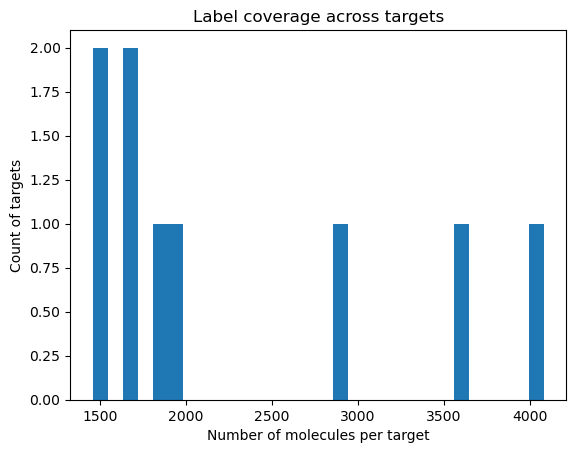

In [48]:
non_nan_counts = np.sum(~np.isnan(multitask_df.values), axis=0)
plt.hist(non_nan_counts, bins=30)
plt.xlabel("Number of molecules per target")
plt.ylabel("Count of targets")
plt.title("Label coverage across targets")
plt.show()

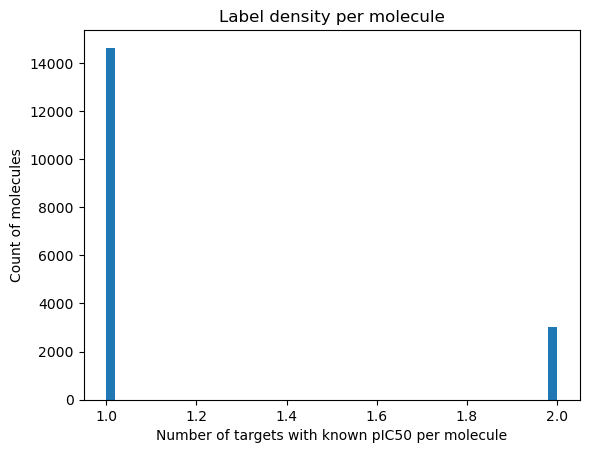

In [49]:
label_counts = multitask_df.notna().sum(axis=1)
plt.hist(label_counts, bins=50)
plt.xlabel("Number of targets with known pIC50 per molecule")
plt.ylabel("Count of molecules")
plt.title("Label density per molecule")
plt.show()

## Training code

In [50]:
def train_epoch_mt(model, loader, optimizer, loss_fn):
    model.train()
    total_loss = 0.0

    for batch in loader:
        # valid_labels = (~torch.isnan(batch.y)).sum().item() # for debugging
        # print(valid_labels)
        # break

        batch = batch.to(device)
        optimizer.zero_grad()

        out = model(batch)  # shape [batch_size, num_tasks]
        batch.y = batch.y.to(out.device)

        # Safety: replace NaNs in predictions
        out = torch.nan_to_num(out, nan=0.0, posinf=1e6, neginf=-1e6)

        # valid_mask = ~torch.isnan(batch.y)
        # num_valid = valid_mask.sum().item()
        # print(f"Batch valid labels: {num_valid}, out.shape: {out.shape}, y.shape: {batch.y.shape}")

        loss = loss_fn(out, batch.y)
        if loss is None or torch.isnan(loss):
            continue  # skip empty batch

        if not torch.isfinite(loss):
            print("⚠️ Skipping batch due to NaN loss.")
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss += loss.item() * batch.num_graphs

    return total_loss / len(loader.dataset)


@torch.no_grad()
def eval_epoch_mt(model, loader, loss_fn):
    model.eval()
    total_loss = 0.0

    for batch in loader:
        # valid_labels = (~torch.isnan(batch.y)).sum().item() # for debugging
        # print(valid_labels)
        # break
  
        batch = batch.to(device)
        out = model(batch)
        batch.y = batch.y.to(out.device)
        out = torch.nan_to_num(out, nan=0.0, posinf=1e6, neginf=-1e6)

        # valid_mask = ~torch.isnan(batch.y) # for debugging
        # num_valid = valid_mask.sum().item()
        # print(f"Batch valid labels: {num_valid}, out.shape: {out.shape}, y.shape: {batch.y.shape}")

        loss = loss_fn(out, batch.y)
        total_loss += loss.item() * batch.num_graphs

    return total_loss / len(loader.dataset)


In [51]:
# def train_with_early_stopping_mt(params):
#     model = GINRegressorMTL(
#         input_dim=params['input_dim'],
#         num_tasks=params['num_tasks'],
#         hidden_dim=params['hidden_dim'],
#         global_feat_dim=params.get('global_feat_dim', 0)
#     ).to(device)
    
#     optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
#     loss_fn = masked_mse_loss

#     best_val_loss = float('inf')
#     patience = 10
#     counter = 0

#     train_losses = []
#     val_losses = []

#     for epoch in range(100):
#         train_loss = train_epoch_mt(model, train_loader, optimizer, loss_fn)
#         val_loss, _, _ = eval_epoch_mt(model, val_loader, loss_fn)

#         train_losses.append(train_loss)
#         val_losses.append(val_loss)

#         print(f"Epoch {epoch+1} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

#         if val_loss < best_val_loss:
#             best_val_loss = val_loss
#             counter = 0
#             torch.save(model.state_dict(), 'best_model_mt.pth')
#         else:
#             counter += 1

#         if counter >= patience:
#             print("Early stopping triggered.")
#             break

#     model.load_state_dict(torch.load('best_model_mt.pth'))

#     return model


With hyperparameter tuning.

In [52]:
param_grid = {
    'lr': [1e-4, 3e-4, 1e-3, 3e-3, 1e-2],  # Learning rates spanning two orders of magnitude
    'hidden_dim': [32, 64, 128, 256],      # Network width
    # 'lr': [1e-4, 3e-4],  # Learning rates spanning two orders of magnitude
    # 'hidden_dim': [64, 128],      # Network width
    # 'num_layers': [2, 3, 5],               # GIN depth - common sweet spots
    # 'dropout': [0.0, 0.2, 0.5],            # Regularisation via dropout
    # 'batch_size': [32, 64, 128],           # Mini-batch sizes
    # 'weight_decay': [0.0, 1e-5, 1e-4],     # L2 regularisation on weights
    # 'readout': ['sum', 'mean', 'max'],     # Different aggregation schemes (depends on your GIN implementation)
    # 'activation': ['relu', 'leakyrelu'],   # Activation function choice
}

In [53]:
import itertools
import matplotlib.pyplot as plt
import torch
import numpy as np

def train_with_early_stopping_mt(params):
    """
    Trains a multi-task GIN model with early stopping and returns the best model.
    """
    # --- Model setup ---
    model = GINRegressorMTL(
        input_dim=params["input_dim"],
        num_tasks=params["num_tasks"],
        hidden_dim=params["hidden_dim"],
        global_feat_dim=params.get("global_feat_dim", 0)
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=params["lr"],
        weight_decay=params.get("weight_decay", 0.0)
    )
    loss_fn = masked_mse_loss

    best_val_loss = float("inf")
    patience = params.get("patience", 10)
    counter = 0

    train_losses, val_losses = [], []

    for epoch in range(params.get("max_epochs", 100)):
        train_loss = train_epoch_mt(model, train_loader, optimizer, loss_fn)
        val_loss = eval_epoch_mt(model, val_loader, loss_fn)  # <-- FIXED unpacking

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1:03d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

        # --- Early stopping ---
        if np.isnan(val_loss) or np.isinf(val_loss):
            print("⚠️ NaN or Inf detected in validation loss — stopping early.")
            break

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), "best_model_mt.pth")
        else:
            counter += 1
            if counter >= patience:
                print("Early stopping triggered.")
                break

    # --- Reload best model ---
    model.load_state_dict(torch.load("best_model_mt.pth"))

    # --- Plot losses ---
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Training and Validation Loss (lr={params['lr']}, hidden_dim={params['hidden_dim']})")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"_images/mt_lr_{params['lr']}_hidden_dim_{params['hidden_dim']}.png", dpi=300)
    plt.close()

    return model


# --- Determine key dimensions dynamically ---
sample_data = data_list[0]
input_dim = sample_data.x.shape[1]
global_feat_dim = getattr(sample_data, "global_features", torch.zeros(0)).shape[0]
num_tasks = multitask_df.shape[1]  # number of receptor targets

# --- Define search grid ---
param_grid = {
    "lr": [1e-4, 3e-4, 1e-3, 3e-3],
    "hidden_dim": [64, 128, 256],
}

best_model = None
best_loss = float("inf")
best_params = None

# --- Run hyperparameter search ---
for lr, hidden_dim in itertools.product(param_grid["lr"], param_grid["hidden_dim"]):
    print(f"\n🔹 Training with lr={lr}, hidden_dim={hidden_dim}")
    params = {
        "lr": lr,
        "hidden_dim": hidden_dim,
        "input_dim": input_dim,
        "global_feat_dim": global_feat_dim,
        "num_tasks": num_tasks,
        "max_epochs": 100,
        "patience": 10,
    }
    
    model = train_with_early_stopping_mt(params)
    val_loss = eval_epoch_mt(model, val_loader, torch.nn.MSELoss())  # <-- FIXED unpacking

    print(f"Validation loss for lr={lr}, hidden_dim={hidden_dim}: {val_loss:.4f}")

    if not np.isnan(val_loss) and val_loss < best_loss:
        best_loss = val_loss
        best_model = model
        best_params = params

print(f"\n🏆 Best params: {best_params}")
print(f"✅ Best validation loss: {best_loss:.4f}")



🔹 Training with lr=0.0001, hidden_dim=64
Epoch 001 | Train: 34.7376 | Val: 54.9821
Epoch 002 | Train: 54.6999 | Val: 54.9821
Epoch 003 | Train: 54.6705 | Val: 54.9821
Epoch 004 | Train: 54.6813 | Val: 54.9821


KeyboardInterrupt: 

Multi task doesn't work - need to loop pver targets and train single_task models.

## Evaluation

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import torch
import matplotlib.pyplot as plt

def evaluate_multitask_regression(model, loader, device, target_names=None):
    """
    Evaluate multitask regression performance with per-target and overall metrics.
    Handles missing (NaN) labels automatically.
    """
    model.eval()
    all_preds, all_trues = [], []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            preds = model(batch)
            y_true = batch.y

            # Convert to numpy
            preds = preds.cpu().numpy()
            y_true = y_true.cpu().numpy()

            all_preds.append(preds)
            all_trues.append(y_true)

    # Stack across all batches
    all_preds = np.vstack(all_preds)
    all_trues = np.vstack(all_trues)

    num_tasks = all_trues.shape[1]
    task_metrics = []

    print("\n📊 Per-target regression metrics:")
    print("-" * 60)

    for i in range(num_tasks):
        mask = ~np.isnan(all_trues[:, i])
        if mask.sum() == 0:
            continue  # skip empty targets

        y_t = all_trues[mask, i]
        y_p = all_preds[mask, i]

        mse = mean_squared_error(y_t, y_p)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_t, y_p)
        r2 = r2_score(y_t, y_p)

        task_name = target_names[i] if target_names is not None else f"Task {i+1}"
        print(f"{task_name:<25s} | RMSE: {rmse:7.4f} | MAE: {mae:7.4f} | R²: {r2:7.4f}")

        task_metrics.append((rmse, mae, r2))

    # Compute macro-averaged metrics across all targets
    task_metrics = np.array(task_metrics)
    mean_rmse, mean_mae, mean_r2 = np.nanmean(task_metrics, axis=0)

    print("-" * 60)
    print(f"Average across {len(task_metrics)} targets -> "
          f"RMSE: {mean_rmse:.4f} | MAE: {mean_mae:.4f} | R²: {mean_r2:.4f}")

    # --- Optional visualization ---
    # Pick one example target (first with enough data)
    for i in range(num_tasks):
        mask = ~np.isnan(all_trues[:, i])
        if mask.sum() > 20:  # arbitrary cutoff to avoid sparse plots
            plt.figure(figsize=(6, 6))
            plt.scatter(all_trues[mask, i], all_preds[mask, i], alpha=0.5)
            plt.plot([all_trues[mask, i].min(), all_trues[mask, i].max()],
                     [all_trues[mask, i].min(), all_trues[mask, i].max()],
                     "r--")
            plt.xlabel("True pIC50")
            plt.ylabel("Predicted pIC50")
            title = target_names[i] if target_names is not None else f"Task {i+1}"
            plt.title(f"True vs Predicted ({title})")
            plt.grid(True)
            plt.tight_layout()
            plt.savefig(f"_images/true_vs_pred_{title.replace(' ', '_')}.png", dpi=300)
            plt.close()
            break  # just plot one for clarity

    return mean_rmse, mean_mae, mean_r2

In [ ]:
mean_rmse, mean_mae, mean_r2 = evaluate_multitask_regression(
    best_model,
    val_loader,
    device,
    target_names=multitask_df.columns.tolist()  # optional
)


If we're going to predict larger molecules, we can and should do some normalisation and stronger regularisation. However, given 4/5 of the folds have similar variance in this metric, we'll go with this model for now but cautiously.

In [ ]:
torch.save({
    "model_state_dict": model.state_dict(),
    "input_dim": input_dim,
    "hidden_dim": hidden_dim,
    "global_feat_dim": global_feat_dim
    }, "class_a_gpcr_pic50_gin.pt")